# Exemple Flowshop (atelier cyclique)

Ce notebook présente l'application de l'algèbre (max,+) aux ateliers de type flowshop cyclique, en reprenant l'exemple du toolbox ScicosLab.

Cette démonstration provient des notes de J.-P. Quadrat *Maxplus Algebra in Scilab and Applications* ([chine.pdf](https://jpquadrat.github.io/chine.pdf) et [boutheon.pdf](https://jpquadrat.github.io/boutheon.pdf)).

## Modèle du Flowshop

- Les **pièces** sont transportées sur des **palettes**. Quand les tâches sur une pièce sont terminées, la palette recommence un cycle avec une autre pièce de la même classe.
- Chaque pièce visite les machines en séquence sans jamais revenir sur la même machine.
- Pour une tâche donnée, on peut avoir plusieurs machines (une « classe »). Les machines visitent les pièces en séquence.
- Le flowshop est défini par une matrice décrivant les ressources utilisées et les temps de traitement.
- Chaque **ligne** de la matrice correspond à une classe de machines.
- Chaque **colonne** correspond à une classe de pièces.
- Les entrées sont les **temps de traitement**.
- Si une classe de pièces n'a pas besoin d'une classe de machines, l'entrée est $-\infty$ (`mp0` ou `ε`).

### Exemple graphique

![Flowshop : graphe d'événements temporisé avec cycle critique en rouge](flowshop.png)

*Figure — Petit flowshop (2 classes de machines `M1`, `M2` × 3 classes de pièces `P1`, `P2`, `P3`) dessiné avec [TimedPetriNetEditor](https://github.com/Lecrapouille/TimedPetriNetEditor). Il s'agit d'un **graphe d'événements temporisé** (sous-classe des réseaux de Petri timed) : pour alléger le dessin, les places ne sont pas représentées explicitement — seuls leurs **jetons** (le point accompagné du nombre, ex. `•1`) et la **durée** de la tâche (le nombre sur l'arc, en unités de temps) sont affichés. Les transitions `M1_P1`, `M2_P2`, … sont les événements « début de la tâche pièce j sur la machine i ».*

**But du modèle.** À partir de ce graphe, on cherche à calculer le **temps de cycle asymptotique** $\lambda$ de l'atelier, c'est-à-dire le temps moyen entre deux passages successifs de chaque pièce. Ce $\lambda$ est la valeur propre (max,+) du graphe et coïncide avec le **circuit critique** : le cycle du graphe dont le rapport (somme des durées) / (somme des jetons) est maximal. C'est lui qui impose la cadence ; toute optimisation passe par l'identification puis l'allègement de ce circuit. **Sur la figure, le circuit critique est tracé en rouge** (les arcs et transitions qui le composent).

Dans la suite, on illustre la boîte à outils Julia `MaxPlus.jl` sur un **flowshop plus complexe** (8 classes de machines × 6 classes de pièces) extrait des notes de J.-P. Quadrat.

In [1]:
push!(LOAD_PATH, pwd())
using MaxPlus, SparseArrays

## Données : temps de traitement `PT`

Le flowshop étudié ici comporte **8 classes de machines** (lignes) et **6 classes de pièces** (colonnes). La matrice `PT` (*Processing Times*) décrit l'**emploi du temps** de l'atelier :

- `PT[i, j]` = durée (en unités de temps, ex. minutes ou heures, au choix de l'utilisateur — l'algèbre (max,+) ne fixe pas l'unité) de la tâche que la classe de machines `i` doit exécuter sur la classe de pièces `j` ;
- une entrée vide `.` correspond à `mp0 = ε = -∞` et signifie *« cette classe de pièces ne passe pas par cette classe de machines »* (pas de tâche, donc pas de contrainte de durée) ;
- une entrée numérique impose à la fois la **ressource utilisée** (la classe de machines `i`) **et** le **temps de traitement**.

Dans l'exemple ci-dessous, lire par exemple `PT[1, 2] = 3.9` signifie : *la pièce de la classe `2` occupe la machine de la classe `1` pendant `3.9` unités de temps*. La dernière ligne (`1.5, 1.5, …`) et l'avant-dernière (`1, 1, …`) modélisent typiquement des étapes communes (manutention, contrôle, …) que toutes les pièces traversent.

In [2]:
PT = MP.([
    2    3.9  0.95 1.1  0.7  1.4
    mp0  mp0  2    1.2  mp0  1.7
    3.7  mp0  2.2  mp0  6.4  mp0
    mp0  mp0  2    mp0  1    1
    1.7  3.1  3    mp0  1.3  mp0
    0.5  3.2  4.3  1.9  1.6  0.4
    1    1    1    1    1    1
    1.5  1.5  1.5  1.2  1.2  1.2
])

8×6 (max,+) dense matrix:
    2   3.9   0.95   1.1   0.7   1.4
    .     .      2   1.2     .   1.7
  3.7     .    2.2     .   6.4     .
    .     .      2     .     1     1
  1.7   3.1      3     .   1.3     .
  0.5   3.2    4.3   1.9   1.6   0.4
    1     1      1     1     1     1
  1.5   1.5    1.5   1.2   1.2   1.2


### Nombre de palettes/machines par classe

La matrice `PT` ne dit pas **combien d'exemplaires** existent pour chaque classe ; cette information est donnée séparément par deux vecteurs `nm` et `np` :

- `nm[i]` = nombre de **machines** disponibles dans la classe `i`. C'est la taille du *buffer* devant cette ressource : une machine ne peut traiter qu'une pièce à la fois, donc `nm[i]` jetons permettent à `nm[i]` pièces d'être servies en parallèle dans cette classe.
- `np[j]` = nombre de **palettes** circulant pour la classe de pièces `j`. Une palette est libérée à la fin du cycle de sa pièce et reprend immédiatement une nouvelle pièce de la même classe ; `np[j]` borne donc le nombre maximal de pièces de la classe `j` en cours de traitement simultané dans l'atelier.

Ces deux vecteurs sont **les leviers d'optimisation** du flowshop : augmenter `nm[i]` ou `np[j]` peut faire baisser le temps de cycle $\lambda$ jusqu'à ce qu'un autre circuit devienne critique.

On commence par lire les dimensions de `PT` puis on choisit le **cas périodique le plus simple** avec une seule machine et une seule palette par classe :

In [3]:
nmach, npiece = size(PT)
println("Nombre de classes de machines : $nmach, Nombre de classes de pièces : $npiece")

nm = ones(Int, nmach)  # 1 machine par classe
np = ones(Int, npiece) # 1 palette par classe

Nombre de classes de machines : 8, Nombre de classes de pièces : 6


6-element Vector{Int64}:
 1
 1
 1
 1
 1
 1

## Graphe (T, N) et analyse spectrale

Le flowshop se représente naturellement par un **graphe d'événements temporisé** (cf. l'exemple en début de notebook) : chaque transition modélise un événement de l'atelier (« début de la tâche pièce $j$ sur machine $i$ »), chaque arc porte une **durée** (temps de traitement) et un **nombre de jetons** (ressources initiales : machines disponibles, palettes prêtes). La fonction `flowshop_graph` extrait de la matrice `PT` et des vecteurs `nm`, `np` deux matrices creuses qui décrivent exactement ce graphe :

- `T[k, ℓ]` = durée portée par l'arc allant de la transition `ℓ` vers la transition `k` (`-∞` s'il n'y a pas d'arc) ;
- `N[k, ℓ]` = nombre de jetons portés par ce même arc.

`T` et `N` partagent la même structure de zéros (mêmes coefficients non nuls) — l'une donne le poids *temps*, l'autre le poids *jetons* de chaque arc.

In [4]:
T, N = flowshop_graph(PT, Float64.(nm), Float64.(np))
println("T : ", size(T), " éléments non-nuls: ", nnz(T))
println("N : ", size(N), " éléments non-nuls: ", nnz(N))

T : (

65, 65) éléments non-nuls: 102
N : (65, 65) éléments non-nuls: 102


### Calcul du débit (Semi-Howard)

**Analyse spectrale en (max,+).** Tout comme en algèbre classique on étudie le comportement asymptotique d'une matrice $A$ via ses valeurs propres ($Ax = \lambda x$), on cherche en (max,+) un scalaire $\lambda$ et un vecteur $v$ tels que

$$A \otimes v = \lambda \otimes v
\quad\text{(en notation classique : } \max_j \bigl(A_{ij} + v_j\bigr) = \lambda + v_i \text{ pour tout } i\text{)}.$$

Une telle $\lambda$ est appelée **valeur propre (max,+)** et le vecteur $v$ est un **vecteur propre**. Pour un graphe d'événements temporisé fortement connexe, la valeur propre est **unique** et représente le **temps de cycle asymptotique** $\lambda$ du système : après une phase transitoire, chaque transition refire toutes les $\lambda$ unités de temps. Le débit (cadence) de l'atelier vaut alors $1 / \lambda$ pièces par unité de temps.

**Algorithme de Howard / Semi-Howard.** Howard (1960) calcule cette valeur propre par *itération sur la politique* : à chaque itération, on choisit pour chaque transition l'arc entrant qui maximise un certain rapport, et on calcule la valeur propre du sous-graphe ainsi sélectionné. La convergence est quadratique en pratique. La variante **Semi-Howard** (Cochet-Terrasson, Cohen, Gaubert, McGettrick, Quadrat) traite directement le couple `(T, N)` d'un graphe d'événements temporisé sans avoir à expliciter la matrice associée.

**Politique retournée.** En plus de la valeur propre, l'algorithme renvoie un *vecteur de politique* (`policy` / champs `r.policy`) : pour chaque transition `k`, il donne le **prédécesseur optimal** choisi à la convergence. Les arcs $(\text{policy}[k] \to k)$ forment le **graphe de politique** ; ses circuits sont exactement les **circuits critiques**, c.-à-d. ceux qui réalisent le maximum (somme des durées) / (somme des jetons) = $\lambda$. C'est ce sous-graphe (en rouge sur la figure d'introduction) qui impose la cadence : si l'on veut faire baisser $\lambda$, c'est sur un arc du circuit critique qu'il faut agir (ajouter une machine, une palette, ou raccourcir une tâche).

In [5]:
r = semihoward(T, N)
λ = plustimes(r.eigenvalues[1])
println("Valeur propre (temps de cycle) : λ = $λ")

Valeur propre (temps de cycle) : λ = 16.95


### Visualiser la politique avec `TimedPetriNetEditor`

`MaxPlus.jl` calcule la valeur propre et la politique, mais ne dessine pas le graphe. Pour **visualiser** le réseau et **mettre en évidence** le circuit critique (la politique retournée par Semi-Howard, en rouge comme sur la figure d'introduction), on utilise l'éditeur compagnon [TimedPetriNetEditor](https://github.com/Lecrapouille/TimedPetriNetEditor) — un éditeur de réseaux de Petri temporisés écrit en **C++** — et son **portage Julia (en cours)** [TimedPetriNetEditor.jl](https://github.com/Lecrapouille/TimedPetriNetEditor.jl).

Le pipeline est simple :

1. `MaxPlus.save_flowshop(PT, nm, np, "demo.flowshop")` écrit un fichier `.flowshop` (pur Julia, aucune dépendance C++).
2. Côté `TimedPetriNetEditor.jl`, `show_cr_graph(PT, nm, np; editor = true)` importe ce fichier dans le moteur C++, calcule le circuit critique et **ouvre l'éditeur graphique** avec les arcs critiques surlignés en rouge.

La fonction renvoie un `NamedTuple` `(success, cycles, durations, eigenvector)`. La cohérence avec `semihoward` est attendue à `1e-9` près :

```julia
using TimedPetriNetEditor
cc = show_cr_graph(PT, nm, np; editor = true)   # affiche le cycle critique
@assert isapprox(maximum(cc.durations), λ; atol = 1e-9)
```

> Prérequis : ce package n'est pas (encore) enregistré. Voir [son README](https://github.com/Lecrapouille/TimedPetriNetEditor.jl) pour les instructions de compilation de la bibliothèque native (toolchain C++ + `glfw`/`glew` pour l'éditeur graphique).

In [6]:
using TimedPetriNetEditor

# `editor = true` ouvre la fenêtre graphique du moteur C++ avec la
# politique (= circuit critique) surlignée en rouge ; mettre `false`
# pour n'avoir que le rapport texte (utile en CI / notebook headless).
cc = show_cr_graph(PT, nm, np; editor = false)

λ_cpp = maximum(cc.durations)
println()
println("Howard (Julia, semihoward) : λ = ", λ)
println("show_cr_graph (C++)        : λ = ", λ_cpp)
println("Cycles trouvés             : ", cc.cycles)
println("Cohérent (atol = 1e-9) ?   : ", isapprox(λ, λ_cpp; atol = 1e-9))

Found 1 connected components of the optimal policy:
  T21 -> T23
  T22 -> T21
  T23 -> T25
  T25 -> T26
  T26 -> T28
  T28 -> T29
  T29 -> T30
  T30 -> T31
  T31 -> T32
  T32 -> T22
Cycle durations [unit of time]:
  T0: 16.95
  T1: 16.95
  T2: 16.95
  T3: 16.95
  T4: 16.95
  T5: 16.95
  T6: 16.95
  T7: 16.95
  T8: 16.95
  T9: 16.95
  T10: 16.95
  T11: 16.95
  T12: 16.95
  T13: 16.95
  T14: 16.95
  T15: 16.95
  T16: 16.95
  T17: 16.95
  T18: 16.95
  T19: 16.95
  T20: 16.95
  T21: 16.95
  T22: 16.95
  T23: 16.95
  T24: 16.95
  T25: 16.95
  T26: 16.95
  T27: 16.95
  T28: 16.95
  T29: 16.95
  T30: 16.95
  T31: 16.95
  T32: 16.95
  T33: 16.95
  T34: 16.95
  T35: 16.95
  T36: 16.95
  T37: 16.95
  T38: 16.95
  T39: 16.95
  T40: 16.95
  T41: 16.95
  T42: 16.95
  T43: 16.95
  T44: 16.95
  T45: 16.95
  T46: 16.95
  T47: 16.95
  T48: 16.95
  T49: 16.95
  T50: 16.95
  T51: 16.95
  T52: 16.95
  T53: 16.95
  T54: 16.95
  T55: 16.95
  T56: 16.95
  T57: 16.95
  T58: 16.95
  T59: 16.95
  T60: 16.95
  T

16.95
show_cr_graph (C++)        : λ = 16.95000022649765
Cycles trouvés             : 1
Cohérent (atol = 1e-9) ?   : false


## Système linéaire (max,+)

La fonction `flowshop` construit le système linéaire (max,+) implicite associé au flowshop :

$$X(n) = D \otimes X(n) \oplus A \otimes X(n-1) \oplus B \otimes U(n)$$
$$Y(n) = C \otimes X(n)$$

### Le flowshop vu comme un système bouclé

Pour passer du graphe d'événements au système linéaire (max,+), on décompose le flowshop en deux morceaux :

- un **système en boucle ouverte** (le flot direct des pièces sur les machines, sans recyclage) : ce sont tous les arcs *autres* que ceux du recyclage des ressources ;
- un **système de rétroaction** qui ferme la boucle, lui-même composé de deux contrôleurs :
  - les arcs **« machines »** qui disent qu'après avoir terminé un cycle de tâches, chaque machine en démarre un nouveau ;
  - les arcs **« palettes »** qui disent qu'aussitôt qu'une pièce a fini son cycle, sa palette repart avec une nouvelle pièce.

On construit alors successivement le système ouvert, les deux contrôleurs, on les compose par rétroaction, on réduit le système implicite en forme explicite, puis on simule. Le code Scilab original de J.-P. Quadrat (à comparer avec le code Julia un peu plus bas) :

```scilab
// Représentation d'état implicite du flowshop en boucle ouverte
s = flowshop(PT)

// Contrôleur des machines
nm = [1. 1. 1. 1. 1. 1. 1. 1.]
fbm = shift(nm(1), 0);
for i = 1:nmach-1, fbm = fbm | shift(nm(i), 0); end;

// Contrôleur des palettes
np = [1. 1. 1. 1. 1. 1.]
fbp = shift(np(1), 0);
for i = 1:npiece-1, fbp = fbp | shift(np(i), 0); end;

// Système bouclé complet
sb = s /. (fbp | fbm);

// Réduction et passage en forme explicite
sbs = explicit(sb);

// Simulation du système bouclé
u = ones(nmach + npiece, 1) * (1:100);
y = simul(sbs, u);
```

C'est exactement ce que fait pour nous la fonction `flowshop_simu` du paragraphe « Simulation » plus bas — mais voyons d'abord le bloc de base utilisé par les contrôleurs : `shift` (renommé `mpshift` en Julia).

In [7]:
s = flowshop(PT)
println("Système flowshop :")
println("  États : ", size(s.A, 1))
println("  Entrées : ", size(s.B, 2))
println("  Sorties : ", size(s.C, 1))

Système flowshop :


  États : 48
  Entrées : 14
  Sorties : 14


## Le registre à décalage `mpshift`

`mpshift(n, t)` est le portage Julia de la fonction `shift` de ScicosLab. C'est un bloc de base **générique** des systèmes linéaires (max,+) : il modélise un **registre à décalage** (delay) de `n` événements avec un décalage temporel `t` sur la première sortie. Concrètement, une fois inséré dans une boucle de rétroaction, il *retient* `n` jetons : autrement dit, il autorise au plus `n` activations simultanées d'une transition aval avant que l'amont ne soit re-déclenché. C'est précisément ce qu'il faut pour modéliser **`n` machines** disponibles dans une classe (`fbm`) ou **`n` palettes** circulant pour une classe de pièces (`fbp`).

Deux primitives suffisent pour décrire les contrôleurs du flowshop :

- `mpshift(n, t)` : registre élémentaire à `n` étages ;
- `|` : **composition diagonale** (mise en parallèle) de deux `MPSysLin`.

Le bloc générique `mpshift` est défini dans `src/syslin.jl` (à côté des autres constructeurs de `MPSysLin`) car il n'est pas spécifique au flowshop : on peut l'utiliser pour construire n'importe quel système (max,+) bouclé.

### Exemple Julia

In [8]:
# Registre à décalage simple : 2 étages, temps initial 0
sh = mpshift(2, 0.0)
println("mpshift(2, 0) :")
println("  Dimension A : ", size(sh.A))
display(sh)

mpshift(2, 0) :
  Dimension A : (3, 3)


Implicit dynamic linear Max-Plus system:
  x(n) = D*x(n) + A*x(n-1) + B*u(n)
  y(n) = C*x(n)
  x(0) = x0

with:
D = 3×3 (max,+) dense matrix:
  .   .   .
  .   .   .
  .   .   .

A = 3×3 (max,+) dense matrix:
  .   0   .
  .   .   0
  .   .   .

B = 3×1 (max,+) dense matrix:
  .
  .
  0

C = 1×3 (max,+) dense matrix:
  0   .   .

x0 = 3×1 (max,+) dense matrix:
  .
  .
  .


In [9]:
# Construction des buffers machines (équivalent Scilab)
fbm = mpshift(nm[1], 0)
for i in 2:nmach
    fbm = fbm | mpshift(nm[i], 0)
end
println("Buffers machines fbm : dimension A = ", size(fbm.A))

# Construction des buffers pièces
fbp = mpshift(np[1], 0)
for i in 2:npiece
    fbp = fbp | mpshift(np[i], 0)
end
println("Buffers pièces fbp : dimension A = ", size(fbp.A))

Buffers machines fbm : dimension A = (

16, 16)
Buffers pièces fbp : dimension A = (12, 12)


## Simulation avec `flowshop_simu`

La fonction `flowshop_simu` encapsule :
1. Construction des buffers machines et pièces (`mpshift` + `|`)
2. Composition avec rétroaction (`/`)
3. Conversion en forme explicite (`explicit`)
4. Simulation (`simul`)
5. Soustraction de la dérive périodique

### Convention des entrées

La matrice `u` suit la convention Scilab :
- **Lignes** = entrées (nmach + npiece)
- **Colonnes** = pas de temps

In [10]:
nt = 10  # nombre de pas de temps
nio = nmach + npiece  # nombre d'entrées
u = ones(Float64, nio, nt)
println("Entrées u : ", size(u), " (lignes=entrées, colonnes=temps)")

Entrées u : (14, 10) (lignes=entrées, colonnes=temps)


In [11]:
chi, y = flowshop_simu(s, nm, np, u)
println("Sorties y : ", size(y), " (lignes=temps, colonnes=sorties)")
println("Valeur propre : ", chi.eigenvalues[1])

Sorties y : (

10, 14) (lignes=temps, colonnes=sorties)
Valeur propre : 16.950000000000003


## Tracés

### Ce que représente `y`

`y` est la matrice retournée par `flowshop_simu`, de taille `(nt, nout)` avec `nout = nmach + npiece = 14` (6 sorties pièces + 8 sorties machines, dans cet ordre). Chaque coefficient `y[k, j]` est **la date** (un instant exprimé dans la même unité de temps que `PT` — secondes, minutes, heures, peu importe : (max,+) ne fixe pas l'unité) à laquelle la sortie `j` *fire* pour la $k$-ième fois :

- pour `j = 1..6` : `y[k, j]` est l'instant auquel la $k$-ième pièce de la classe `j` **sort de l'atelier** (fin du cycle palette) ;
- pour `j = 7..14` : `y[k, j]` est l'instant auquel la machine de la classe `j − 6` **achève son $k$-ième cycle de tâches**.

L'axe horizontal `k` est sans unité : c'est le **compteur d'événements** (le numéro de cycle, $k = 1, 2, …, 100$), pas un temps réel.

### Pourquoi soustraire $\lambda \cdot k$ ?

Asymptotiquement, le flowshop est strictement périodique : chaque sortie *fire* toutes les $\lambda \approx 16.95$ unités de temps. Sans correction, on aurait donc :

$$y[k, j] \;\xrightarrow[k \to \infty]{}\; \lambda \cdot k + b_j$$

c'est-à-dire 14 droites parallèles de pente $\lambda$ — l'écran serait illisible et on ne verrait ni le transitoire ni la structure périodique. La fonction `flowshop_simu` **retranche donc la dérive linéaire $\lambda \cdot k$** avant de retourner `y`. Ce qui est tracé est en fait $\tilde y[k, j] = y[k, j] - \lambda \cdot k$, c'est-à-dire l'**écart à la cadence nominale** :

- $\tilde y > 0$ : la sortie a pris du retard sur la cadence asymptotique ;
- $\tilde y = $ constante : la sortie tourne exactement à la cadence $\lambda$ ;
- $\tilde y$ qui oscille avec un motif de longueur $T$ : la sortie est périodique de période $T$ à la cadence moyenne $\lambda$.

L'axe vertical reste exprimé en **unités de temps de `PT`** (même unité que les coefficients de la matrice).

### Cas de périodicité 1 (`m = p = 1`)

Avec une seule machine et une seule palette par classe, chaque transition est re-déclenchée **exactement une fois par période $\lambda$**. Une fois la dérive `λ·k` retirée, les 14 courbes $\tilde y[:, j]$ **convergent vers des constantes** $b_j$ (les offsets de chaque sortie par rapport à la cadence) : on observe d'abord un **transitoire** (le système doit remplir l'atelier de jetons) puis des **plateaux horizontaux**. C'est la signature d'un régime stationnaire de **période 1** : tous les $\lambda$ pas de temps, chaque sortie produit un événement.

In [12]:
using Plots
Plots.default(size = (760, 400), legend = :outerright)

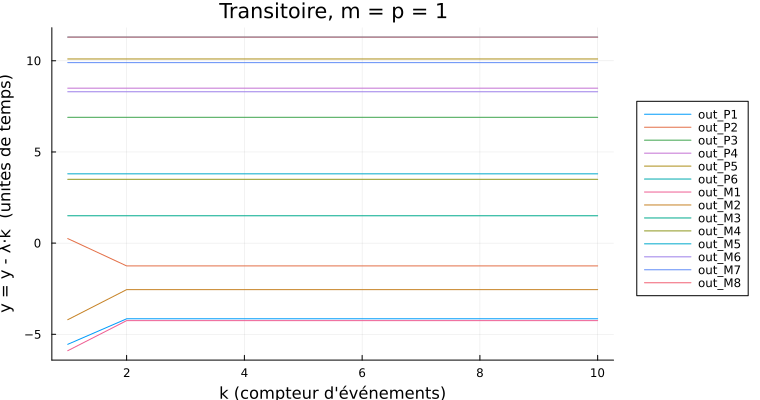

In [13]:
labels = vcat(["out_P$j" for j in 1:npiece], ["out_M$i" for i in 1:nmach])
p = plot(title = "Transitoire, m = p = 1",
         xlabel = "k (compteur d'événements)",
         ylabel = "ỹ = y - λ·k  (unités de temps)")
for j in 1:size(y, 2)
    plot!(p, 1:size(y, 1), y[:, j]; label = labels[j])
end
display(p)

### Cas de périodicité 3 (`m = p = 3`)

On passe maintenant à **3 machines par classe** et **3 palettes par classe de pièces**. Avec ces buffers supplémentaires, chaque transition peut être servie *en parallèle* trois fois avant d'attendre une ressource ; à l'asymptote, les sorties oscillent donc selon un **régime périodique de période 3** (trois trajectoires entrelacées, chacune réplique de la précédente décalée d'un tiers de période). Visuellement : les courbes $\tilde y[:, j] = y[:, j] - \lambda \cdot k$ ne sont plus plates après le transitoire, mais montrent un motif qui se répète exactement tous les 3 pas. C'est la signature d'un flowshop dont le débit asymptotique reste $1/\lambda$, mais où le régime stationnaire est de longueur 3 au lieu de 1 — d'où le terme « périodicité 3 ». (L'axe $y$ reste en *unités de temps de `PT`*.)

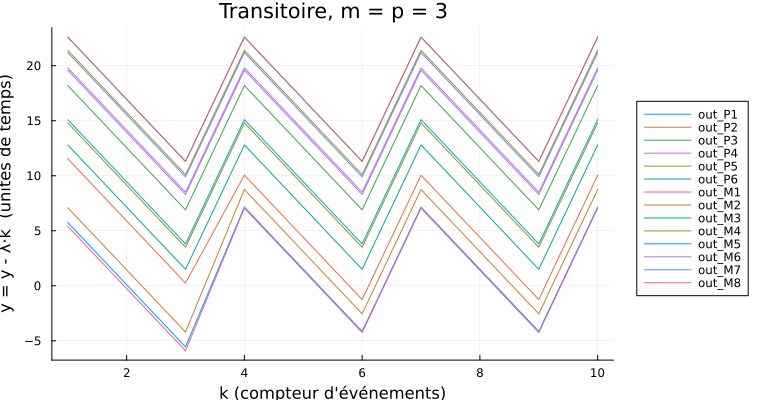

In [14]:
nm3 = fill(3, nmach)
np3 = fill(3, npiece)
_, y3 = flowshop_simu(s, nm3, np3, u)

p2 = plot(title = "Transitoire, m = p = 3",
          xlabel = "k (compteur d'événements)",
          ylabel = "ỹ = y - λ·k  (unités de temps)")
for j in 1:size(y3, 2)
    plot!(p2, 1:size(y3, 1), y3[:, j]; label = labels[j])
end
display(p2)

## Récapitulatif des fonctions

| Fonction Julia | Équivalent Scilab | Description |
|----------------|-------------------|-------------|
| `mpshift(n, t)` | `shift(n, t)` | Registre à décalage de n étages |
| `S1 \| S2` | `S1 \| S2` | Composition diagonale (parallèle) |
| `S1 / S2` | `S1 /. S2` | Composition avec rétroaction |
| `explicit(S)` | `explicit(S)` | Conversion forme implicite → explicite |
| `simul(S, u, history)` | `simul(S, u)` | Simulation du système |
| `flowshop(PT)` | `flowshop(PT)` | Construction du système flowshop |
| `flowshop_graph(PT, nm, np)` | `flowshop_graph(PT, nm, np)` | Graphe (T, N) du flowshop |
| `flowshop_simu(s, nm, np, u)` | (script manuel) | Simulation complète encapsulée |
| `semihoward(T, N)` | `semihoward(T, N)` | Algorithme Semi-Howard |